<div style="display:inline-block;vertical-align:top;">
<img src= "https://urosario.edu.co/static/getmedia/4b482c72-87c2-49a5-8e81-14312e6270f0/logo-Medicina_Mesa-de-trabajo-1" width=500>


</div>

# **Seminario Tendencias de la Inteligencia Artificial en Salud**
## ***Machine Learning* (ML) para Aplicaciones en Salud**

###**Aprendizaje Supervisado - Clasificación**

Alvaro David Orjuela Cañón

alvaro.orjuela@urosario.edu.co

<img src="https://images.shiksha.com/mediadata/ugcDocuments/images/wordpressImages/2022_04_image-63.jpg" width=500>

# **Aprendizaje Supervisado**

Necesita datos entrada-salida para que el modelo aprenda que para cada vector de entrada hay una salida que debe aprender.

Realizaremos dos ejemplos:

*  **Parte 1: Clasificación** Necesita las **etiquetas** o clases que debe aprender

*  **Parte 2: Regresión:** Necesita **los valores** que debe aprender





## **Conjunto de Datos**

Supongamos que tenemos estos datos

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/master/supervisado5.png?raw=true" alt="centered image" width="700" height="200"></center>
<br>

donde,

- ***Pregnancies***: Número de embarazos que ha tenido en su vida
- ***Glucose***: Nivel de concentración de glucosa en sangre
- ***BloodPressure***: Presión arterial
- ***SkinThikness***: Espesor de piel a la altura del triceps
- ***Insulin***: Respuesta a dosis de insulina en 2 horas
- ***BMI***: Índice de masa corporal
- ***DiabetesPedigreeFunction***: Presencia de diabetes en ascendencia directa
- ***Age***: Edad del paciente
- ***Outcome***: Variable que queremos predecir:
   - $1$ : Tiene diabetes
   - $0$ : No tiene diabetes

***Problema***: Predecir si una mujer, con ciertos valores en las variables antes mencionadas tiene o no diabetes.

**Importamos Librerías:**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**Utilizamos la API de Kaggle para obtener los datos**

In [ ]:
!curl -L -o /content/diabetes-data-set.zip\
  https://www.kaggle.com/api/v1/datasets/download/mathchi/diabetes-data-set

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  9128  100  9128    0     0   7583      0  0:00:01  0:00:01 --:--:--     0


In [ ]:
# Descomprimimos el archivo
!unzip /content/diabetes-data-set.zip

Archive:  /content/diabetes-data-set.zip
  inflating: diabetes.csv            


In [ ]:
dataset = pd.read_csv("/content/diabetes.csv")
dataset

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
dataset.mean()

,0
Pregnancies,3.845052
Glucose,120.894531
BloodPressure,69.105469
SkinThickness,20.536458
Insulin,79.799479
BMI,31.992578
DiabetesPedigreeFunction,0.471876
Age,33.240885
Outcome,0.348958


## **Clasificación Binaria**

En este caso tomamos las primeras 8 columnas y clasificamos en los salida en:
* Activo (Diabético): 1
* Inactivo (No Diabético): 0

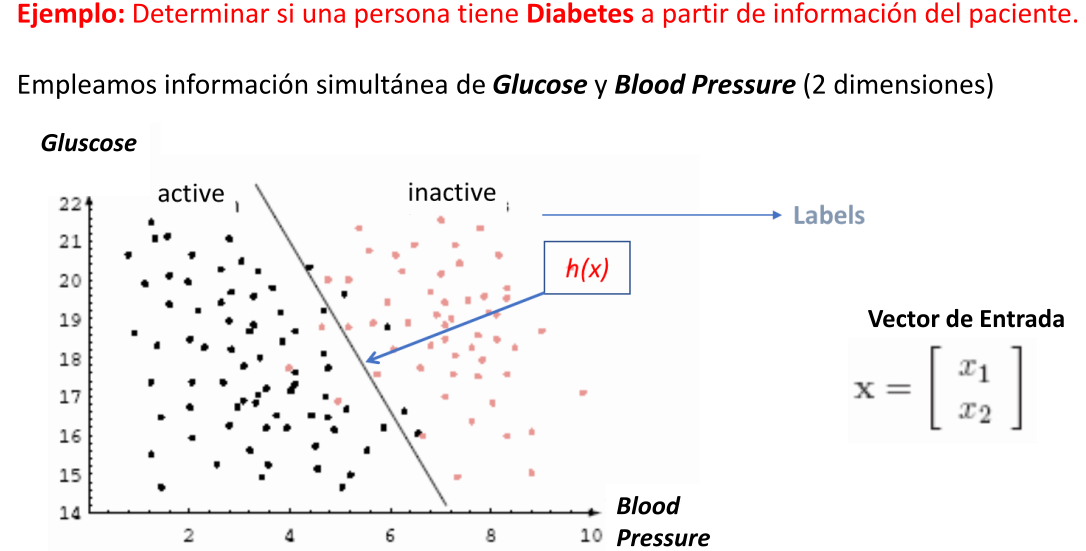

### **División del Conjunto de Datos**

En *Machine Learning* es necesario dividir el conjunto de datos en dos o tres subconjuntos:
* **Entrenamiento o ajuste (Training, Fitting):** este subconjunto permite ajustar los parámetros del modelo (conocidos como hiperparámetros) buscando disminuir un error (**Accuracy**)
* **Validación:** este subconjunto permite que el modelo no se sobreajuste (*overfitting*) solo con los datos del entrenamiento
* **Test:** este subconjunto generalmente evalúa qué tan bueno es el modelo ante datos nunca antes vistos

<img src="https://images.tpointtech.com/tutorial/machine-learning/images/train-and-test-datasets-in-machine-learning.png" width=400>

Formamos únicamente dos subconjuntos una **train** y otro **test** de forma **manual**

In [ ]:
Train, y_Train = dataset[:int(len(dataset)*0.7)].iloc[:,:-1], dataset[:int(len(dataset)*0.7)].iloc[:,-1]
Test, y_Test = dataset[int(len(dataset)*0.7):].iloc[:,:-1], dataset[int(len(dataset)*0.7):].iloc[:,-1]

Train.shape, y_Train.shape, Test.shape, y_Test.shape

((537, 8), (537,), (231, 8), (231,))

Podemos hacer la división automática y aleatoria.

**¡Bienvenida la librería [Scikit-Learn](https://scikit-learn.org/stable/)!**

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/0/05/Scikit_learn_logo_small.svg/1200px-Scikit_learn_logo_small.svg.png" width=300>

In [ ]:
# Entrenamos un modelo ML
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Separamos los datos
X = dataset.iloc[:,:-1]/np.max(dataset.iloc[:,:-1])
Y = dataset.iloc[:,-1]
# Data split
Train, Test, y_train, y_test = train_test_split(X, Y, test_size=0.3)  #<------------
# Proponemos el primer modelo de ML
model1 = MLPClassifier(solver='lbfgs', hidden_layer_sizes=(10,10), max_iter=100, activation = 'tanh')
# Entrenamos
model1.fit(Train, y_train)
# Realizamos predicción
yhat_Train1 = model1.predict(Train)
# Calculamos el Accuracy
Accuracy_train1 = accuracy_score(y_train, yhat_Train1)
Accuracy_train1

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


0.7523277467411545

In [ ]:
# Hacemos evaluación estadísticas

Resultados_train = list()
Resultados_test = list()

for i in range(100):
  # Proponemos el primer modelo de ML
  model1 = MLPClassifier(solver='lbfgs', hidden_layer_sizes=(10,10), max_iter=100, activation = 'tanh', random_state=i)
  # Entrenamos
  model1.fit(Train, y_train)
  # Realizamos predicción
  yhat_Train1 = model1.predict(Train)
  # Calculamos el Accuracy
  Accuracy_train1 = accuracy_score(y_train, yhat_Train1)
  Resultados_train.append(Accuracy_train1)
  # --- Resultados del Test
  yhat_Test = model1.predict(Test)
  Accuracy_test = accuracy_score(y_test, yhat_Test)
  Resultados_test.append(Accuracy_test)


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS R

(array([ 1.,  0.,  1.,  0.,  2.,  3.,  0.,  9., 10., 12., 13., 15., 12.,
         0.,  5.,  4.,  8.,  4.,  0.,  1.]),
 array([0.73593074, 0.73961039, 0.74329004, 0.7469697 , 0.75064935,
        0.754329  , 0.75800866, 0.76168831, 0.76536797, 0.76904762,
        0.77272727, 0.77640693, 0.78008658, 0.78376623, 0.78744589,
        0.79112554, 0.79480519, 0.79848485, 0.8021645 , 0.80584416,
        0.80952381]),
 <BarContainer object of 20 artists>)

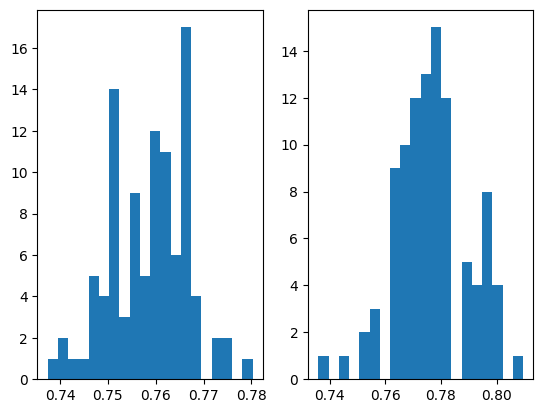

In [ ]:
# Figura para los histogramas

plt.subplot(1,2,1)
plt.hist(Resultados_train, bins=20)
plt.subplot(1,2,2)
plt.hist(Resultados_test, bins=20)




**Analizamos en el conjunto de datos de Test**

In [ ]:
yhat_Test = model1.predict(Test)
Accuracy_test = accuracy_score(y_test, yhat_Test)
Accuracy_test

0.7662337662337663

**Matriz de Confusión**

<img src="https://www.sharpsightlabs.com/wp-content/uploads/2023/09/sklearn-confusion-matrix_visual-example.png" width=400>

In [ ]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, yhat_Test)

array([[134,  23],
       [ 31,  43]])

**Support Vector Machines**

In [ ]:
from sklearn import svm

model2 = svm.SVC(C = 10000, kernel='poly')
model2.fit(Train, y_train)

yhat_Train2 = model2.predict(Train)
Accuracy_train2 = accuracy_score(y_train, yhat_Train2)
Accuracy_train2

0.8044692737430168

In [ ]:
# Test
yhat_Test2 = model2.predict(Test)
Accuracy_test2 = accuracy_score(y_test, yhat_Test2)
Accuracy_test2

0.7835497835497836

## **Clasificación Multiclase**

En este caso tomamos las primeras 13 columnas y clasificamos en los 5 estados la salida (5 Clases)

Primero **los datos**, utilizaremos los datos del repositorio de la Universidad de California, **aquí:** (https://archive.ics.uci.edu/)

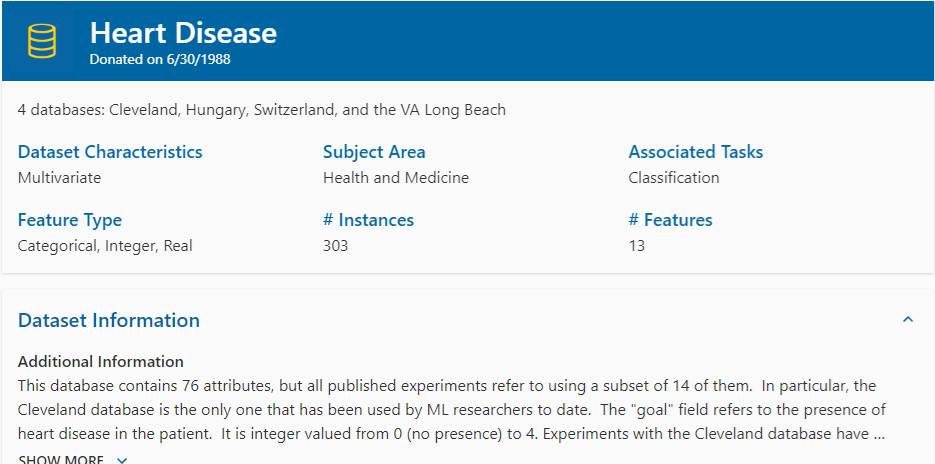



Esta pequeña base de datos posee información asociada al riesgo de tener **cardiopatía** o [Heart Disease](https://archive.ics.uci.edu/dataset/45/heart+disease). Existen 14 atributos o entradas en la base de datos y su salida puede ser un nivel de riesgo de tener la cardiopatía en 5 niveles [0, 1, 2, 3, 4].

Para obtener los datos podemos descargarlos directamente del repositorio, sin necesidad de descargar y guardarlo en nuestro drive local.

### **Conjunto de Datos**

**1) Instalamos la API de los repositorios de UCI**

In [ ]:
!pip install ucimlrepo

**2) Obtenemos el dataset**

Tener presente el tipo de los datos importados porque en este caso están en Pandas

In [ ]:
from ucimlrepo import fetch_ucirepo

# Obtenemos el dataset
heart_disease = fetch_ucirepo(id=45) # El ID 45 es de la base de datos de cardiopatia

# Datos (en formato pandas dataframes)
X = heart_disease.data.features
y = heart_disease.data.targets

# metadata
print(heart_disease.metadata)

# variable information
print(heart_disease.variables)

{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

In [ ]:
type(X)

pandas.core.frame.DataFrame

In [ ]:
X.mean()

,0
age,54.438944
sex,0.679868
cp,3.158416
trestbps,131.689769
chol,246.693069
fbs,0.148515
restecg,0.990099
thalach,149.607261
exang,0.326733
oldpeak,1.039604


In [ ]:
X.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


**3) Importamos las librerías necesarias para análisis de datos**

In [ ]:
import numpy as np
import pandas as pd

Podemos calcular el tamaño del *dataset* y mostrarla usando el formato de pandas

In [ ]:
np.shape(X), np.shape(y)

((303, 13), (303, 1))

In [ ]:
dataset = pd.concat([X, y], axis=1)
dataset

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0,1
299,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0,2
300,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0,3
301,57,0,2,130,236,0,2,174,0,0.0,2,1.0,3.0,1


Verificamos el nuevo tamaño de la variable ***dataset*** y realizamos una pequeña limpieza, quitando los valores vacios o *not a number* - **NA**

In [ ]:
dataset.shape

(303, 14)

### **División del Conjunto de Datos**

En *Machine Learning* es necesario dividir el conjunto de datos en dos o tres subconjuntos:
* **Entrenamiento o ajuste (Training, Fitting):** este subconjunto permite ajustar los parámetros del modelo (conocidos como hiperparámetros) buscando disminuir un error (MSE)
* **Validación:** este subconjunto permite que el modelo no se sobreajuste (*overfitting*) solo con los datos del entrenamiento
* **Test:** este subconjunto generalmente evalúa qué tan bueno es el modelo ante datos nunca antes vistos

In [ ]:
dataset = dataset.dropna()
# Revisar que no existan valores diferentes a los números
dataset.shape

(297, 14)

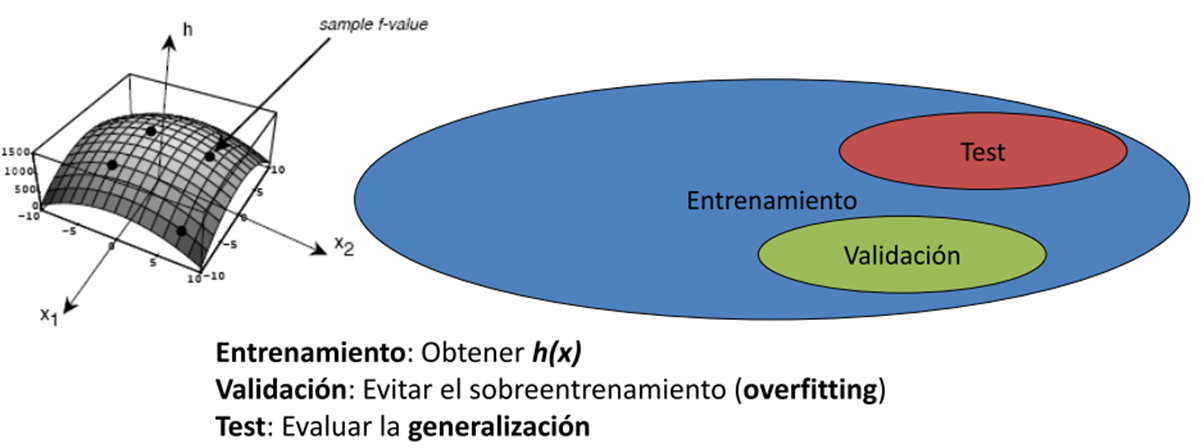

Formamos únicamente dos subconjuntos una **train** y otro **test** de forma **manual**

In [ ]:
Train, y_Train = dataset[:int(len(dataset)*0.7)].iloc[:,:5], dataset[:int(len(dataset)*0.7)].iloc[:,5]
Test, y_Test = dataset[int(len(dataset)*0.7):].iloc[:,:5], dataset[int(len(dataset)*0.7):].iloc[:,5]

Train.shape, y_Train.shape, Test.shape, y_Test.shape

((207, 5), (207,), (90, 5), (90,))

In [ ]:
dataset=dataset.dropna()

In [ ]:
# Entrenamos un modelo ML
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Separamos los datos
X = dataset.iloc[:,:13]/np.max(dataset.iloc[:,:13])
Y = dataset.iloc[:,13]
# Data split
Train, Test, y_train, y_test = train_test_split(X, Y, test_size=0.3)  #<------------

<Axes: >

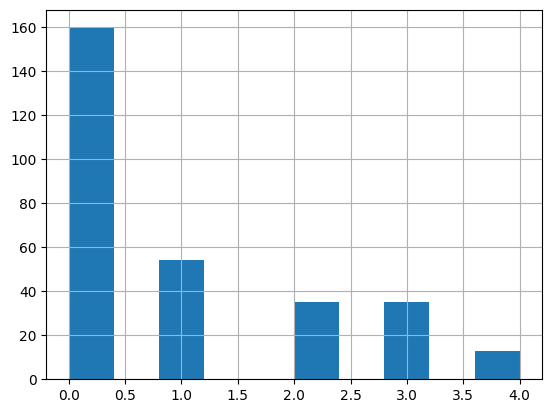

In [ ]:
Y.hist()

In [ ]:
# Proponemos el primer modelo de ML
model1 = MLPClassifier(solver='lbfgs', hidden_layer_sizes=(10, 10), max_iter=200, activation = 'tanh', random_state=23)
# Entrenamos
model1.fit(Train, y_train)
# Realizamos predicción
yhat_Train1 = model1.predict(Train)
# Calculamos el R2 score
Accuracy_train1 = accuracy_score(y_train, yhat_Train1)
Accuracy_train1

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


0.6473429951690821

In [ ]:
model1.solver

'lbfgs'

In [ ]:
yhat_Test = model1.predict(Test)
Accuracy_test = accuracy_score(y_test, yhat_Test)
Accuracy_test

0.5666666666666667

In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, yhat_Test)

array([[42,  2,  0,  1,  1],
       [ 6,  3,  3,  3,  0],
       [ 2,  3,  2,  5,  0],
       [ 1,  3,  5,  4,  0],
       [ 0,  1,  0,  3,  0]])

Confusion matrix, without normalization
Normalized confusion matrix


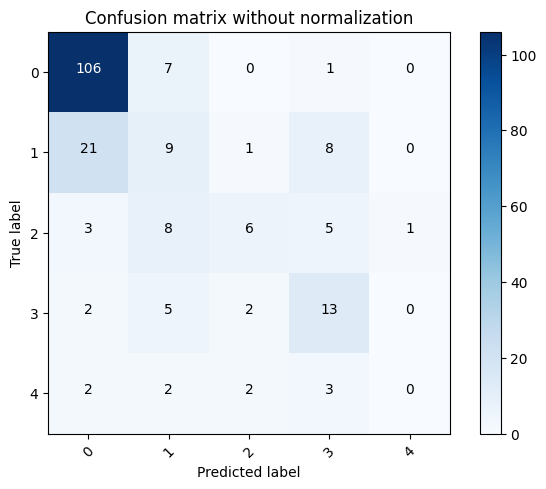

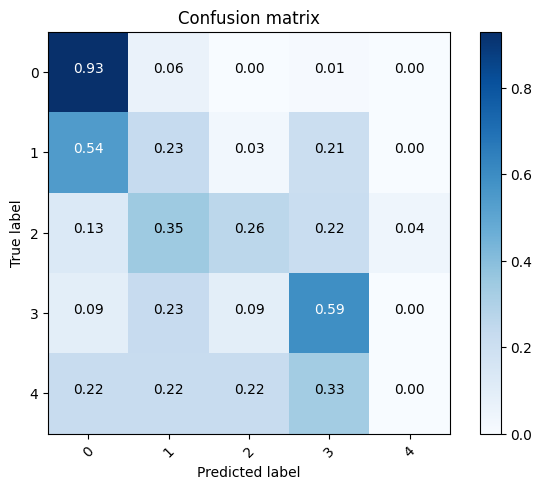

In [ ]:
Clases = ['0','1','2','3','4']

import itertools
from sklearn.metrics import confusion_matrix, accuracy_score
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

#    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Compute confusion matrix- TEST (o TRAIN)
cnf_matrix = confusion_matrix(y_train, yhat_Train1)
np.set_printoptions(precision=2)

# Plot non-normalized confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=Clases, title='Confusion matrix without normalization')

# Plot normalized confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=Clases, normalize=True)#, title='Normalized confusion matrix')

plt.show()

Calculamos resultados para el subconjunto de **test**

In [ ]:
# Realizamos predicción
yhat_Test1 = model1.predict(Test)
# Calculamos el R2 score
Accuracy_test1 = accuracy_score(y_test, yhat_Test1)
Accuracy_test1

0.6111111111111112

Matriz de confusión para el subconjunto de **test**

Confusion matrix, without normalization
Normalized confusion matrix


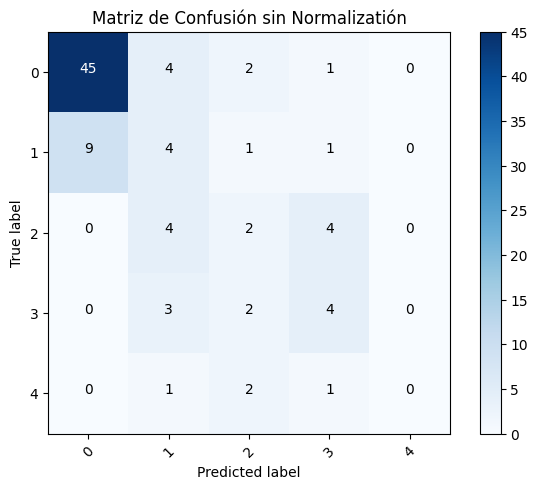

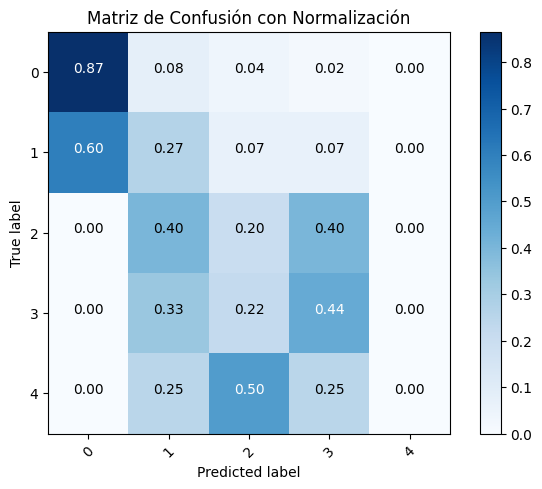

In [ ]:
# Compute confusion matrix- TEST (o TRAIN)
cnf_matrix = confusion_matrix(y_test, yhat_Test1)
np.set_printoptions(precision=2)

# Plot non-normalized confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=Clases, title='Matriz de Confusión sin Normalizatión')

# Plot normalized confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=Clases, normalize=True, title='Matriz de Confusión con Normalización')

plt.show()